## Decision Tree Algorithm

#### Install Libraries and Import Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report)

#### Load Data

In [2]:
base_dir = "overall/overall"
CLASS_NAMES = ["Fake", "Real"]
def load_texts(folder, label):
    folder_path = os.path.join(base_dir, folder)
    texts = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                texts.append(f.read())
    return pd.DataFrame({"text": texts, "label": label})
fakeDF = load_texts("fake", 0)
legitDF = load_texts("real", 1)
df = pd.concat([fakeDF, legitDF], ignore_index=True)
print("Sample rows:")
print(df.head())
print("\nLabel distribution:")
print(df["label"].value_counts())

Sample rows:
                                                text  label
0  Kim Kardashian Changed Her Password Again Afte...      0
1  ‘Bird Box’ Challenge: Man Crashes After Attemp...      0
2  29 Humans Killed in Laboratory\nProducing Mili...      0
3  Bart Simpson elected mayor of LA town\nThe Sim...      0
4  Jaden Smith Says He is a Prophet and God Inspi...      0

Label distribution:
label
0    290
1    290
Name: count, dtype: int64


#### Exploratory Data Analysis

In [3]:
def plot_class_distribution(labels, title):
    counts = np.bincount(labels)
    plt.figure(figsize=(6, 4))
    plt.bar(CLASS_NAMES, counts, color=["#e74c3c", "#2ecc71"])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Documents")
    plt.tight_layout()
    plt.show()

#### Preprocessing  (TF-IDF)

In [4]:
def split_and_vectorize(df):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X = vectorizer.fit_transform(df["text"]).toarray()
    Y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.3, random_state=100
    )
    return X_train, X_test, y_train, y_test, vectorizer

#### Training Functions

In [5]:
def train_gini(X_train, y_train):
    clf = DecisionTreeClassifier(
        criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5
    )
    clf.fit(X_train, y_train)
    return clf
def train_entropy(X_train, y_train):
    clf = DecisionTreeClassifier(
        criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5
    )
    clf.fit(X_train, y_train)
    return clf
def train_decision_tree(X_train, y_train):
    """Basic Decision Tree (no depth limit) — mirrors the GFG article."""
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    return clf
def train_random_forest(X_train, y_train):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    return clf
def train_svm(X_train, y_train):
    clf = SVC(kernel="linear", random_state=42)
    clf.fit(X_train, y_train)
    return clf

#### Evation Helpers

In [6]:
def evaluate(model_name, y_test, y_pred):
    print(f"\n{'=' * 50}")
    print(f"  {model_name}")
    print(f"{'=' * 50}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(
        "\nClassification Report:\n",
        classification_report(y_test, y_pred, target_names=CLASS_NAMES),
    )
def plot_decision_tree(clf, feature_names):
    plt.figure(figsize=(18, 10))
    plot_tree(
        clf,
        filled=True,
        feature_names=feature_names,
        class_names=CLASS_NAMES,
        rounded=True,
        max_depth=3,          # keeps the plot readable
    )
    plt.title("Decision Tree (Gini)")
    plt.tight_layout()
    plt.show()
def plot_accuracy_comparison(results):
    names = list(results.keys())
    scores = [v * 100 for v in results.values()]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, scores, color=["#3498db", "#9b59b6", "#e67e22", "#1abc9c"])
    plt.ylim(0, 100)
    plt.ylabel("Accuracy (%)")
    plt.title("Model Accuracy Comparison")
    for bar, score in zip(bars, scores):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{score:.1f}%",
            ha="center",
            fontsize=10,
        )
    plt.tight_layout()
    plt.show()

#### Main

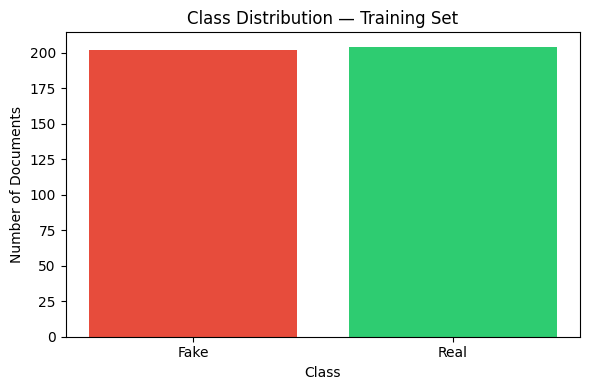

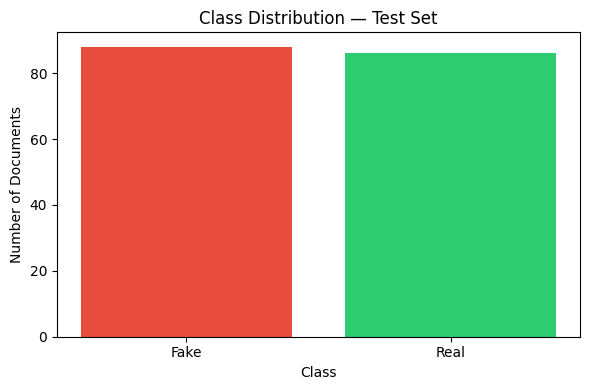


  Decision Tree (Gini)
Confusion Matrix:
 [[80  8]
 [59 27]]

Accuracy: 61.49%

Classification Report:
               precision    recall  f1-score   support

        Fake       0.58      0.91      0.70        88
        Real       0.77      0.31      0.45        86

    accuracy                           0.61       174
   macro avg       0.67      0.61      0.58       174
weighted avg       0.67      0.61      0.58       174



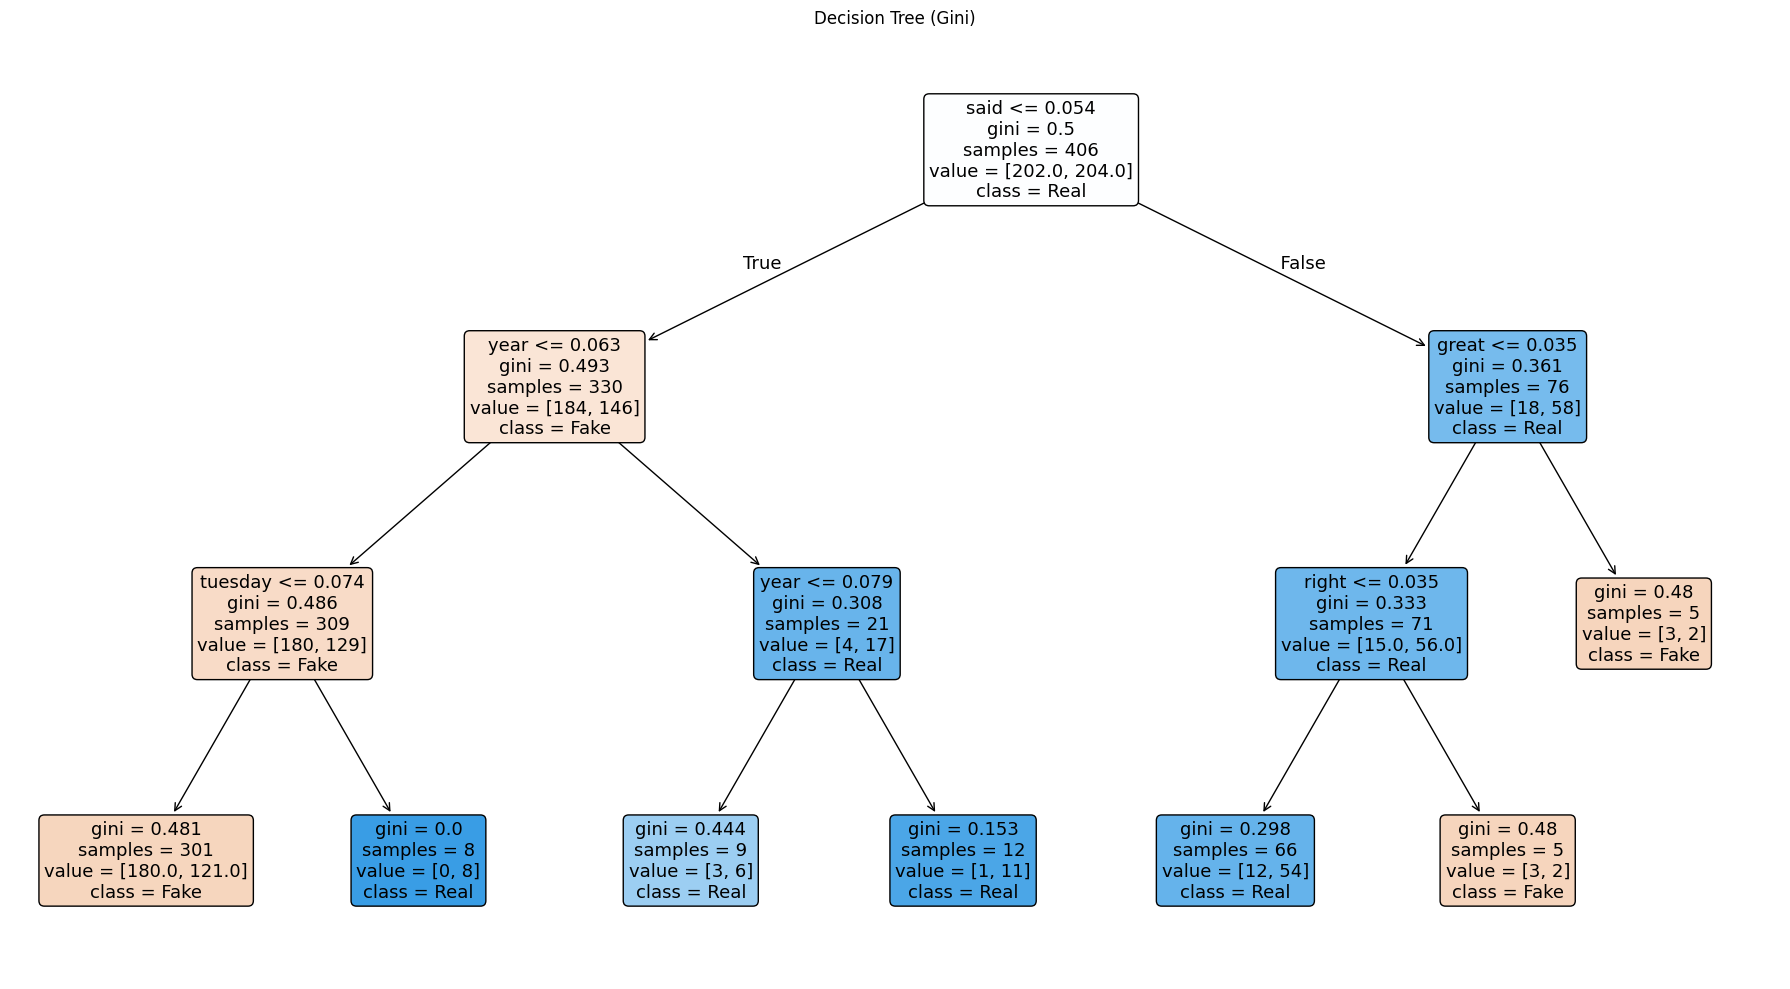


  Decision Tree (Entropy)
Confusion Matrix:
 [[79  9]
 [62 24]]

Accuracy: 59.20%

Classification Report:
               precision    recall  f1-score   support

        Fake       0.56      0.90      0.69        88
        Real       0.73      0.28      0.40        86

    accuracy                           0.59       174
   macro avg       0.64      0.59      0.55       174
weighted avg       0.64      0.59      0.55       174


  Decision Tree (No depth limit)
Confusion Matrix:
 [[54 34]
 [48 38]]

Accuracy: 52.87%

Classification Report:
               precision    recall  f1-score   support

        Fake       0.53      0.61      0.57        88
        Real       0.53      0.44      0.48        86

    accuracy                           0.53       174
   macro avg       0.53      0.53      0.52       174
weighted avg       0.53      0.53      0.53       174


  Random Forest (100 estimators)
Confusion Matrix:
 [[59 29]
 [52 34]]

Accuracy: 53.45%

Classification Report:
         

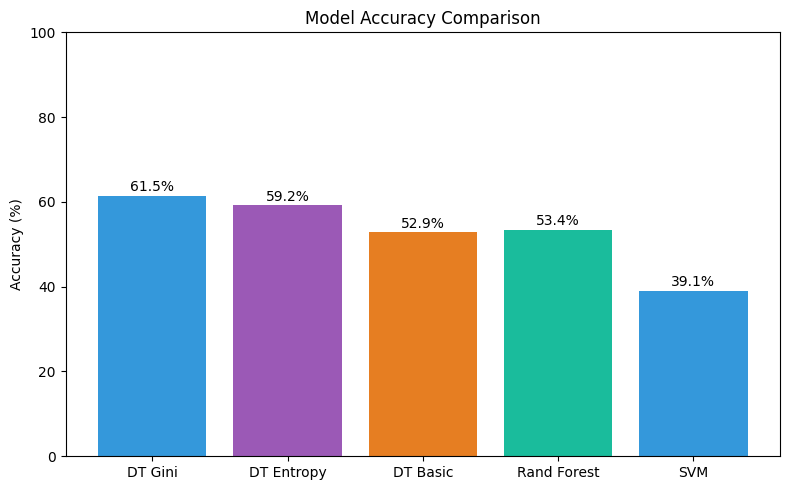

In [7]:
if __name__ == "__main__":
    # --- Preprocess ---
    X_train, X_test, y_train, y_test, vectorizer = split_and_vectorize(df)
    feature_names = vectorizer.get_feature_names_out()
    # --- EDA plots ---
    plot_class_distribution(y_train, "Class Distribution — Training Set")
    plot_class_distribution(y_test, "Class Distribution — Test Set")
    # --- Decision Tree: Gini ---
    clf_gini = train_gini(X_train, y_train)
    y_pred_gini = clf_gini.predict(X_test)
    evaluate("Decision Tree (Gini)", y_test, y_pred_gini)
    plot_decision_tree(clf_gini, feature_names)
    # --- Decision Tree: Entropy ---
    clf_entropy = train_entropy(X_train, y_train)
    y_pred_entropy = clf_entropy.predict(X_test)
    evaluate("Decision Tree (Entropy)", y_test, y_pred_entropy)
    # --- Basic Decision Tree (GFG style, no depth limit) ---
    clf_dt = train_decision_tree(X_train, y_train)
    y_pred_dt = clf_dt.predict(X_test)
    evaluate("Decision Tree (No depth limit)", y_test, y_pred_dt)
    # --- Random Forest ---
    clf_rf = train_random_forest(X_train, y_train)
    y_pred_rf = clf_rf.predict(X_test)
    evaluate("Random Forest (100 estimators)", y_test, y_pred_rf)
    # --- SVM ---
    clf_svm = train_svm(X_train, y_train)
    y_pred_svm = clf_svm.predict(X_test)
    evaluate("SVM (linear kernel)", y_test, y_pred_svm)
    # --- Summary plot ---
    results = {
        "DT Gini":    accuracy_score(y_test, y_pred_gini),
        "DT Entropy": accuracy_score(y_test, y_pred_entropy),
        "DT Basic":   accuracy_score(y_test, y_pred_dt),
        "Rand Forest": accuracy_score(y_test, y_pred_rf),
        "SVM":        accuracy_score(y_test, y_pred_svm),
    }
    plot_accuracy_comparison(results)

## Best Case Analysis (Time Complexity)

For the Decision Tree algorithm, the best-case scenario occurs when the dataset is perfectly separable by a single feature. This results in a tree of depth 1, also known as a "Decision Stump". In this scenario, predicting a new sample takes $O(1)$ time complexity because the algorithm only needs to check a single condition at the root node to reach a classification result.

In [8]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import time

# Define dataset sizes for testing execution time
sizes = [100, 200, 300, 400]
print("Decision Tree Best Case Execution Times (Depth = 1):")
dt_best_times = []

for n in sizes:
    # Subsetting the data using the names from your screenshot
    # We use .toarray() only if it's a sparse matrix
    X_sub = X_train[:n]
    y_sub = y_train[:n]
    
    # Force the tree to depth 1 to represent the best case scenario
    clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    clf.fit(X_sub, y_sub)
    
    # Prepare a single test sample for prediction
    sample = X_test[0].reshape(1, -1)
    
    start_time = time.time()
    # Predict the class (Best case complexity: O(1) traversal)
    clf.predict(sample)
    end_time = time.time()
    
    execution_time = end_time - start_time
    dt_best_times.append(execution_time)
    print(f"n={n}:\t {execution_time:.6f} seconds")

Decision Tree Best Case Execution Times (Depth = 1):
n=100:	 0.000384 seconds
n=200:	 0.000191 seconds
n=300:	 0.000131 seconds
n=400:	 0.000189 seconds


### Best Case Example:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import time

def decision_tree_best_case_predict(example_text, vectorizer, X_train, y_train):
    x = vectorizer.transform([example_text])
    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,        # keeps tree balanced
        min_samples_split=2,
        random_state=42
    )

    dt.fit(X_train, y_train)

    start = time.time()
    prediction = dt.predict(x)[0]
    end = time.time()

    label = "Real" if prediction == 1 else "Fake"
    print(f"Best-Case Decision Tree predicts: {label}")
    print(f"Prediction time: {end - start:.8f} seconds")

    return label

example_text = """Government officials confirmed today that the new environmental policy 
will be implemented nationwide next month after weeks of expert review."""

# Run best-case prediction
decision_tree_best_case_predict(example_text, vectorizer, X_train_vec, y_train)



Best-Case Decision Tree predicts: Real
Prediction time: 0.00014782 seconds


'Real'

### Average‑Case Example

In [10]:
example = ['''Several online posts claimed that new transportation plans were approved this week,
but no official announcement has been released. Some users said they heard about the changes from unnamed sources.''']

example_vec = vectorizer.transform(example)

fakeReal= "Real" if clf_dt.predict(example_vec) else "Fake" 
print("Decision Tree Predects that the Example is", fakeReal)

Decision Tree Predects that the Example is Real


I chose this example because it is a neutral news text with slight uncertainty, making it suitable for testing the average case where algorithms may disagree

## Average‑Case speed Analysis 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
import time
import numpy as np

# Clean X_train and X_test 
X_train_clean = [str(x[0]) if isinstance(x, (list, np.ndarray)) else str(x) for x in X_train]
X_test_clean = [str(x[0]) if isinstance(x, (list, np.ndarray)) else str(x) for x in X_test]

# Convert text data into numerical vectors using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)

# Different training sizes to measure prediction time
sizes = [500, 1000, 2000, 4000, X_train_vec.shape[0]]
times = []

for n in sizes:
    dt = DecisionTreeClassifier()

    X_sub = X_train_vec[:n]
    y_sub = y_train[:n]

    dt.fit(X_sub, y_sub)

    start = time.time()
    dt.predict(X_test_vec[:1])
    end = time.time()

    times.append(end - start)

for s, t in zip(sizes, times):
    print(f"n={s}: prediction time = {t:.6f} seconds")

n=500: prediction time = 0.000211 seconds
n=1000: prediction time = 0.000373 seconds
n=2000: prediction time = 0.000345 seconds
n=4000: prediction time = 0.000239 seconds
n=406: prediction time = 0.000174 seconds


In the average case, the Decision Tree model gives very fast predictions. 
After training, the model already knows how to split the data, so predicting a new sample only requires moving through a few steps in the tree. 
This makes prediction time almost the same no matter how big the training set is. 
The model does most of the work during training which is why prediction becomes quick and efficient.

## Worst Case Analysis (Time Complexity)

In [12]:
import time
import numpy as np

print("=== WORST CASE ANALYSIS: DECISION TREE (GINI) ===")

dt_times = []

for i in range(5):
    print(f"\nRun {i+1}:")

    start = time.perf_counter()
    _ = clf_gini.predict(X_test)
    end = time.perf_counter()

    dt_time = (end - start) * 1000
    dt_times.append(dt_time)

    print(f"Decision Tree (Gini) Time: {dt_time:.4f} ms")

print("\n=== AVERAGE RESULTS ===")
print(f"Decision Tree (Gini) Average Time (all runs): {np.mean(dt_times):.4f} ms")

print("\n=== IMPROVED AVERAGE RESULTS ===")
print(f"Decision Tree (Gini) Average Time (excluding first run): {np.mean(dt_times[1:]):.4f} ms")

=== WORST CASE ANALYSIS: DECISION TREE (GINI) ===

Run 1:
Decision Tree (Gini) Time: 2.0381 ms

Run 2:
Decision Tree (Gini) Time: 1.8943 ms

Run 3:
Decision Tree (Gini) Time: 1.5999 ms

Run 4:
Decision Tree (Gini) Time: 1.4371 ms

Run 5:
Decision Tree (Gini) Time: 1.2984 ms

=== AVERAGE RESULTS ===
Decision Tree (Gini) Average Time (all runs): 1.6536 ms

=== IMPROVED AVERAGE RESULTS ===
Decision Tree (Gini) Average Time (excluding first run): 1.5574 ms


### Worst Case Example: 

In [13]:
example_vec = X_test[0].reshape(1, -1)

pred = clf_gini.predict(example_vec)[0]

fakeReal = "Real" if pred == 1 else "Fake"
print("Decision Tree Predicts that the Example is", fakeReal)

Decision Tree Predicts that the Example is Real
